<a href="https://colab.research.google.com/github/shushruthareddy123/Resume-Screening-Machine-Learning/blob/main/Resume_Screening_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Resume Screening & Ranking System
### Comparing TF-IDF + Cosine Similarity vs Sentence-BERT
**Dataset:** 9,000 resumes across 9 IT job categories


## 1. Setup & Imports

In [4]:
# Install required packages
!pip install sentence-transformers scikit-learn pandas numpy matplotlib seaborn wordcloud -q

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sentence_transformers import SentenceTransformer

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
print('✅ All imports successful')

✅ All imports successful


## 2. Load & Explore Dataset

In [13]:
df = pd.read_csv('Resume dataset.csv', on_bad_lines='skip', engine='python')
print(f'Dataset Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nMissing values:\n{df.isnull().sum()}')
df.head(2)

Dataset Shape: (9000, 3)
Columns: ['category', 'job_title', 'Text']

Missing values:
category     0
job_title    0
Text         0
dtype: int64


,category,job_title,Text
0,Java Developers/Architects Resumes,Java Developer,Flair for technology and willing to take chall...
1,Java Developers/Architects Resumes,Sr. Java/J2EE Developer,Senior Java Developer with around 7+ years of ...


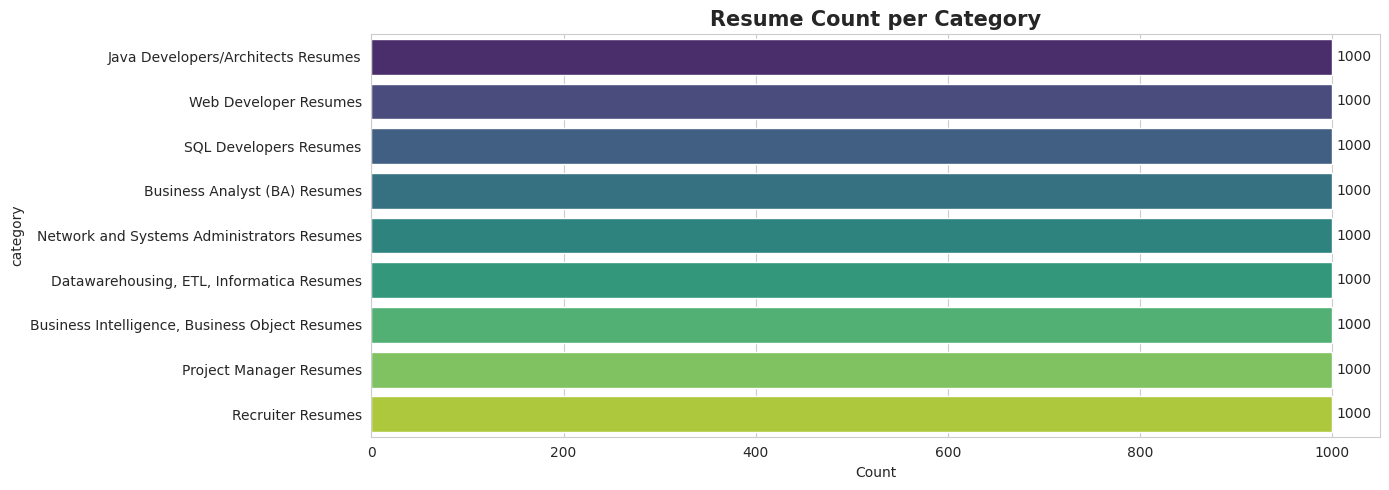

category
Java Developers/Architects Resumes                1000
Web Developer Resumes                             1000
SQL Developers Resumes                            1000
Business Analyst (BA) Resumes                     1000
Network and Systems Administrators Resumes        1000
Datawarehousing, ETL, Informatica Resumes         1000
Business Intelligence, Business Object Resumes    1000
Project Manager Resumes                           1000
Recruiter Resumes                                 1000
Name: count, dtype: int64


In [14]:
# Category Distribution
cat_counts = df['category'].value_counts()

plt.figure(figsize=(14, 5))
ax = sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='viridis')
plt.title('Resume Count per Category', fontsize=15, fontweight='bold')
plt.xlabel('Count')
for i, v in enumerate(cat_counts.values):
    ax.text(v + 5, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('eda_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(cat_counts)

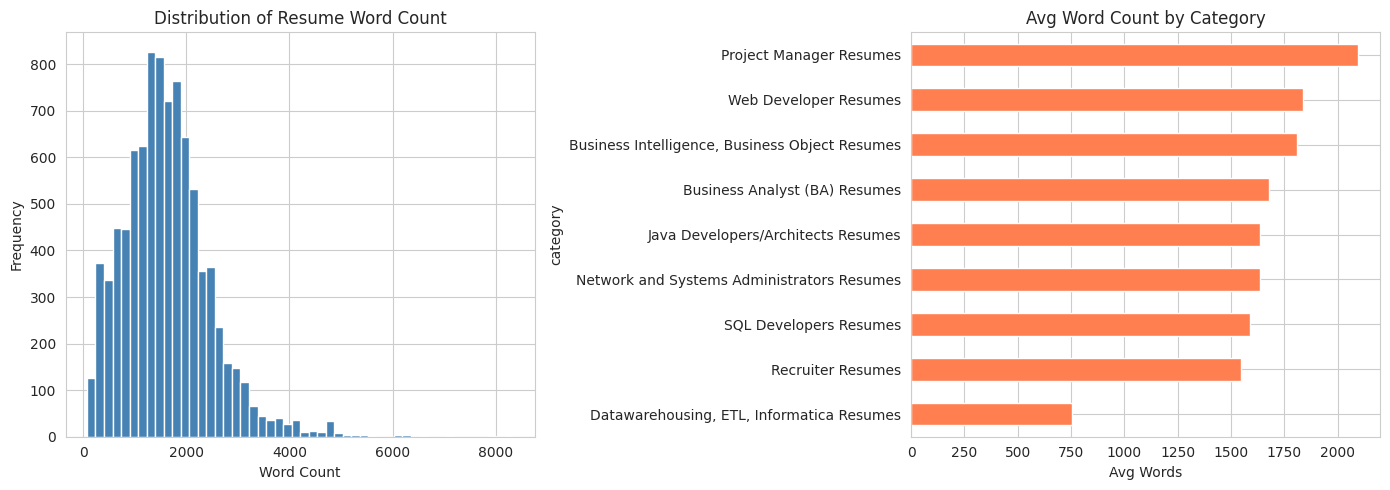

count    9000.000000
mean     1618.590778
std       840.723871
min        76.000000
25%      1041.500000
50%      1542.000000
75%      2060.000000
max      8341.000000
Name: text_length, dtype: float64


In [15]:
# Text Length Analysis
df['text_length'] = df['Text'].str.split().str.len()

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
df['text_length'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Resume Word Count')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df.groupby('category')['text_length'].mean().sort_values().plot(kind='barh', color='coral')
plt.title('Avg Word Count by Category')
plt.xlabel('Avg Words')
plt.tight_layout()
plt.savefig('eda_text_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(df['text_length'].describe())

## 3. Text Preprocessing

In [16]:
def preprocess_text(text):
    """Clean and normalize resume text."""
    if pd.isna(text):
        return ''
    text = str(text).lower()
    # Remove special characters but keep alphanumeric + spaces
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['Text'].apply(preprocess_text)

print('Sample cleaned text (first 300 chars):')
print(df['clean_text'].iloc[0][:300])
print(f'\n✅ Preprocessed {len(df)} resumes')

Sample cleaned text (first 300 chars):
flair for technology and willing to take challenging assignments with over 6 years of versatile experience in analysis design development and implementation of n tier architecture based applications business to business applications business to client based applications distributed components intern

✅ Preprocessed 9000 resumes


## 4. Define Sample Job Descriptions
We create one sample JD per category to test our screening system.

In [17]:
JOB_DESCRIPTIONS = {
    'Java Developer': """
        We are looking for a Java Developer with 5+ years of experience in J2EE,
        Spring Boot, Hibernate, REST APIs, Maven, and SQL databases.
        Experience with microservices, Agile/Scrum methodology required.
        Knowledge of Docker, Kubernetes, and CI/CD pipelines is a plus.
    """,
    'Web Developer': """
        Seeking a Web Developer skilled in HTML5, CSS3, JavaScript, React or Angular,
        Node.js, REST APIs. Experience with responsive design, cross-browser compatibility,
        and Git version control. Familiarity with AWS or Azure deployment is beneficial.
    """,
    'SQL Developer': """
        We need an SQL Developer with strong skills in writing complex T-SQL/PL-SQL queries,
        stored procedures, indexing, performance tuning, ETL processes, and SSRS reporting.
        Experience with SQL Server or Oracle required.
    """,
    'Business Analyst': """
        Looking for a Business Analyst who can gather requirements, create BRDs,
        conduct gap analysis, facilitate stakeholder meetings, and produce process flow diagrams.
        Experience with JIRA, Confluence, and Agile methodology required.
    """,
    'Network Administrator': """
        Hiring a Network and Systems Administrator with experience in LAN/WAN,
        firewalls, VPN, routers, switches, TCP/IP, DNS, DHCP.
        Certifications such as CCNA or CompTIA Network+ preferred.
    """,
    'ETL Developer': """
        ETL Developer with experience in Informatica PowerCenter, data warehousing,
        data modeling, SSIS, SQL, and relational databases.
        Strong understanding of star schema and snowflake schema preferred.
    """,
    'BI Developer': """
        Business Intelligence Developer with hands-on experience in Tableau, Power BI,
        Business Objects, SSRS, data visualization, DAX, and SQL.
        Ability to create dashboards and translate business metrics into insights.
    """,
    'Project Manager': """
        Project Manager with PMP certification and 7+ years experience in managing
        software delivery, budget control, risk management, stakeholder communication,
        and Agile/Waterfall methodologies. MS Project or JIRA experience required.
    """,
    'Technical Recruiter': """
        Technical Recruiter with experience in full-cycle recruiting, IT sourcing,
        LinkedIn talent search, ATS management, and stakeholder coordination.
        Strong understanding of technical roles across software development.
    """,
}

print(f'✅ Defined {len(JOB_DESCRIPTIONS)} job descriptions')
for title in JOB_DESCRIPTIONS:
    print(f'  • {title}')

✅ Defined 9 job descriptions
  • Java Developer
  • Web Developer
  • SQL Developer
  • Business Analyst
  • Network Administrator
  • ETL Developer
  • BI Developer
  • Project Manager
  • Technical Recruiter


## 5. Approach 1 — TF-IDF + Cosine Similarity

In [18]:
# ── Build TF-IDF vectorizer on all resume text ──
print('Building TF-IDF matrix...')
start = time.time()

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True
)

tfidf_matrix = tfidf.fit_transform(df['clean_text'])
elapsed = time.time() - start

print(f'✅ TF-IDF Matrix shape: {tfidf_matrix.shape}')
print(f'⏱  Built in {elapsed:.2f}s')

Building TF-IDF matrix...
✅ TF-IDF Matrix shape: (9000, 10000)
⏱  Built in 39.68s


In [19]:
def screen_resumes_tfidf(job_description, top_n=10):
    """
    Given a job description, rank all resumes using TF-IDF cosine similarity.
    Returns a DataFrame with top_n matching resumes.
    """
    clean_jd = preprocess_text(job_description)
    jd_vec = tfidf.transform([clean_jd])
    scores = cosine_similarity(jd_vec, tfidf_matrix).flatten()

    top_idx = scores.argsort()[::-1][:top_n]
    results = df.iloc[top_idx][['category', 'job_title']].copy()
    results['tfidf_score'] = scores[top_idx].round(4)
    results['rank'] = range(1, top_n + 1)
    return results.reset_index(drop=True)


# ── Demo: screen for Java Developer ──
print('\n🔍 TF-IDF Screening for: Java Developer')
print('=' * 60)
results_tfidf = screen_resumes_tfidf(JOB_DESCRIPTIONS['Java Developer'], top_n=10)
print(results_tfidf.to_string(index=False))


🔍 TF-IDF Screening for: Java Developer
                                  category                                                          job_title  tfidf_score  rank
                         Recruiter Resumes                                             Sr. Software Developer       0.1526     1
Network and Systems Administrators Resumes Lead Cloud Solutions Architecture & Cloud Application Architecture       0.1352     2
Network and Systems Administrators Resumes                                                    DevOps Engineer       0.1349     3
Network and Systems Administrators Resumes                                      Build and Release Coordinator       0.1349     4
Network and Systems Administrators Resumes                                                    DevOps Engineer       0.1349     5
Network and Systems Administrators Resumes                                Sr. Build & Release Engineer/DevOps       0.1349     6
Network and Systems Administrators Resumes               

In [20]:
# ── Evaluate TF-IDF: How often does top result match expected category? ──

CATEGORY_MAP = {
    'Java Developer':       'Java Developers/Architects Resumes',
    'Web Developer':        'Web Developer Resumes',
    'SQL Developer':        'SQL Developers Resumes',
    'Business Analyst':     'Business Analyst (BA) Resumes',
    'Network Administrator':'Network and Systems Administrators Resumes',
    'ETL Developer':        'Datawarehousing, ETL, Informatica Resumes',
    'BI Developer':         'Business Intelligence, Business Object Resumes',
    'Project Manager':      'Project Manager Resumes',
    'Technical Recruiter':  'Recruiter Resumes',
}

tfidf_precision = {}

for jd_title, jd_text in JOB_DESCRIPTIONS.items():
    expected_cat = CATEGORY_MAP[jd_title]
    top10 = screen_resumes_tfidf(jd_text, top_n=10)
    hits = (top10['category'] == expected_cat).sum()
    tfidf_precision[jd_title] = hits / 10

print('\n📊 TF-IDF Precision@10 (fraction of top-10 from correct category):')
print('=' * 60)
for title, score in tfidf_precision.items():
    bar = '█' * int(score * 20)
    print(f'{title:<28} {score:.0%}  {bar}')
print(f'\nAverage Precision@10: {np.mean(list(tfidf_precision.values())):.1%}')


📊 TF-IDF Precision@10 (fraction of top-10 from correct category):
Java Developer               0%  
Web Developer                0%  
SQL Developer                0%  
Business Analyst             0%  
Network Administrator        100%  ████████████████████
ETL Developer                0%  
BI Developer                 20%  ████
Project Manager              20%  ████
Technical Recruiter          0%  

Average Precision@10: 15.6%


## 6. Approach 2 — Sentence-BERT Embeddings

In [21]:
# ── Load Sentence-BERT model ──
print('Loading Sentence-BERT model (all-MiniLM-L6-v2)...')
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
print('✅ Model loaded')

Loading Sentence-BERT model (all-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded


In [22]:
# ── Encode all resumes (truncate to first 512 words for speed) ──
print('Encoding resumes with Sentence-BERT...')
start = time.time()

# Truncate text for faster encoding
truncated_texts = df['clean_text'].str.split().str[:256].str.join(' ').tolist()

sbert_embeddings = sbert_model.encode(
    truncated_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

elapsed = time.time() - start
print(f'✅ Embeddings shape: {sbert_embeddings.shape}')
print(f'⏱  Encoded in {elapsed:.1f}s')

Encoding resumes with Sentence-BERT...


Batches:   0%|          | 0/141 [00:00<?, ?it/s]

✅ Embeddings shape: (9000, 384)
⏱  Encoded in 1236.5s


In [23]:
def screen_resumes_sbert(job_description, top_n=10):
    """
    Given a job description, rank resumes using Sentence-BERT cosine similarity.
    Returns a DataFrame with top_n matching resumes.
    """
    jd_vec = sbert_model.encode([preprocess_text(job_description)])
    scores = cosine_similarity(jd_vec, sbert_embeddings).flatten()

    top_idx = scores.argsort()[::-1][:top_n]
    results = df.iloc[top_idx][['category', 'job_title']].copy()
    results['sbert_score'] = scores[top_idx].round(4)
    results['rank'] = range(1, top_n + 1)
    return results.reset_index(drop=True)


# ── Demo: screen for Java Developer ──
print('\n🔍 SBERT Screening for: Java Developer')
print('=' * 60)
results_sbert = screen_resumes_sbert(JOB_DESCRIPTIONS['Java Developer'], top_n=10)
print(results_sbert.to_string(index=False))


🔍 SBERT Screening for: Java Developer
                          category           job_title  sbert_score  rank
Java Developers/Architects Resumes Java/J2EE Developer       0.7195     1
Java Developers/Architects Resumes      Java Developer       0.7195     2
Java Developers/Architects Resumes Java/J2EE Developer       0.7195     3
                 Recruiter Resumes           Developer       0.7055     4
Java Developers/Architects Resumes      Lead Developer       0.7055     5
                 Recruiter Resumes    Senior Associate       0.6952     6
Java Developers/Architects Resumes    Senior Associate       0.6952     7
Java Developers/Architects Resumes    Senior Associate       0.6952     8
Java Developers/Architects Resumes      Java Developer       0.6937     9
Java Developers/Architects Resumes      Java Developer       0.6937    10


In [24]:
# ── Evaluate SBERT: Precision@10 ──
sbert_precision = {}

for jd_title, jd_text in JOB_DESCRIPTIONS.items():
    expected_cat = CATEGORY_MAP[jd_title]
    top10 = screen_resumes_sbert(jd_text, top_n=10)
    hits = (top10['category'] == expected_cat).sum()
    sbert_precision[jd_title] = hits / 10

print('\n📊 SBERT Precision@10 (fraction of top-10 from correct category):')
print('=' * 60)
for title, score in sbert_precision.items():
    bar = '█' * int(score * 20)
    print(f'{title:<28} {score:.0%}  {bar}')
print(f'\nAverage Precision@10: {np.mean(list(sbert_precision.values())):.1%}')


📊 SBERT Precision@10 (fraction of top-10 from correct category):
Java Developer               80%  ████████████████
Web Developer                0%  
SQL Developer                0%  
Business Analyst             0%  
Network Administrator        100%  ████████████████████
ETL Developer                0%  
BI Developer                 0%  
Project Manager              0%  
Technical Recruiter          0%  

Average Precision@10: 20.0%


## 7. Compare Both Approaches

In [25]:
# ── Side-by-side comparison ──
comparison_df = pd.DataFrame({
    'Job Role': list(tfidf_precision.keys()),
    'TF-IDF P@10': list(tfidf_precision.values()),
    'SBERT P@10': list(sbert_precision.values())
})
comparison_df['Winner'] = comparison_df.apply(
    lambda r: 'SBERT' if r['SBERT P@10'] > r['TF-IDF P@10']
    else ('TF-IDF' if r['TF-IDF P@10'] > r['SBERT P@10'] else 'Tie'), axis=1
)

print('\n📊 Head-to-Head Comparison')
print('=' * 65)
print(comparison_df.to_string(index=False))
print('\nOverall Average:')
print(f'  TF-IDF: {comparison_df["TF-IDF P@10"].mean():.1%}')
print(f'  SBERT:  {comparison_df["SBERT P@10"].mean():.1%}')


📊 Head-to-Head Comparison
             Job Role  TF-IDF P@10  SBERT P@10 Winner
       Java Developer          0.0         0.8  SBERT
        Web Developer          0.0         0.0    Tie
        SQL Developer          0.0         0.0    Tie
     Business Analyst          0.0         0.0    Tie
Network Administrator          1.0         1.0    Tie
        ETL Developer          0.0         0.0    Tie
         BI Developer          0.2         0.0 TF-IDF
      Project Manager          0.2         0.0 TF-IDF
  Technical Recruiter          0.0         0.0    Tie

Overall Average:
  TF-IDF: 15.6%
  SBERT:  20.0%


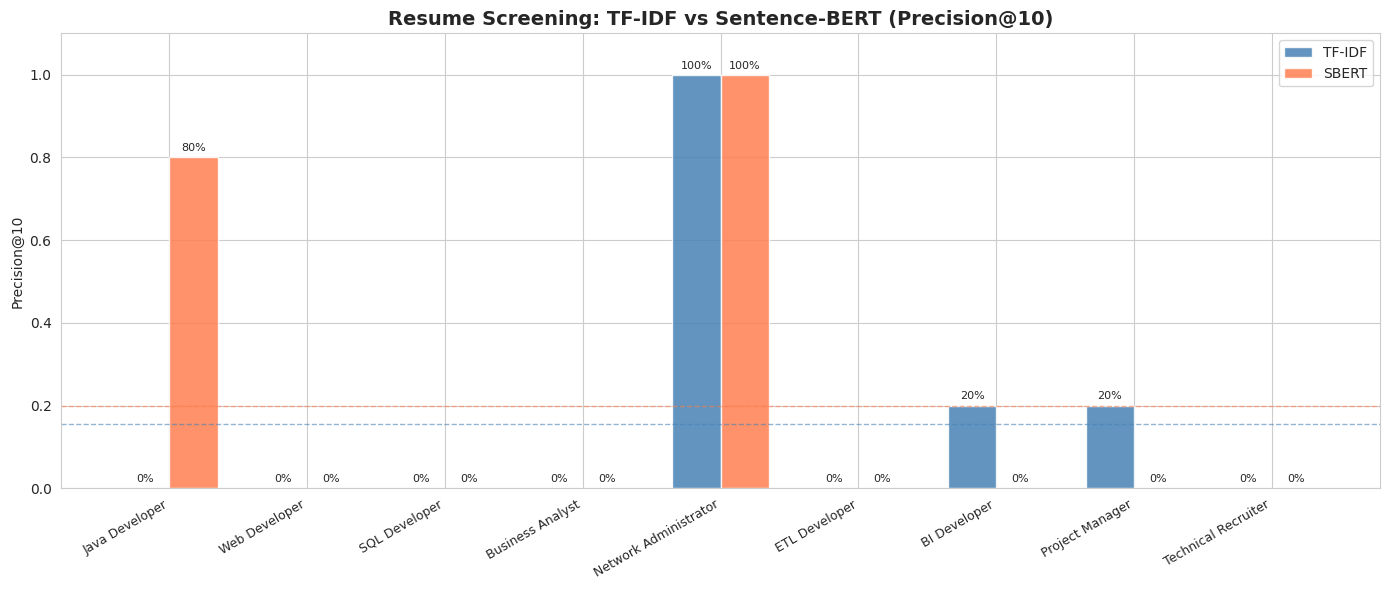

In [26]:
# ── Visualization: Precision@10 bar chart ──
x = np.arange(len(comparison_df))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, comparison_df['TF-IDF P@10'], width, label='TF-IDF', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, comparison_df['SBERT P@10'], width, label='SBERT', color='coral', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Job Role'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Precision@10')
ax.set_ylim(0, 1.1)
ax.set_title('Resume Screening: TF-IDF vs Sentence-BERT (Precision@10)', fontsize=14, fontweight='bold')
ax.legend()
ax.axhline(comparison_df['TF-IDF P@10'].mean(), color='steelblue', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(comparison_df['SBERT P@10'].mean(), color='coral', linestyle='--', linewidth=1, alpha=0.6)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('comparison_precision.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. TF-IDF Classification Baseline
Trainning a Logistic Regression classifier on TF-IDF features to predict resume category.

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['category'])
X = tfidf_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = LogisticRegression(max_iter=500, C=1.0, solver='lbfgs', multi_class='multinomial')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'✅ TF-IDF + Logistic Regression Accuracy: {acc:.2%}\n')
print(classification_report(y_test, y_pred, target_names=le.classes_))

✅ TF-IDF + Logistic Regression Accuracy: 86.78%

                                                precision    recall  f1-score   support

                 Business Analyst (BA) Resumes       0.96      0.93      0.95       200
Business Intelligence, Business Object Resumes       0.88      0.94      0.91       200
     Datawarehousing, ETL, Informatica Resumes       0.88      0.93      0.90       200
            Java Developers/Architects Resumes       0.74      0.73      0.74       200
    Network and Systems Administrators Resumes       0.87      0.87      0.87       200
                       Project Manager Resumes       0.97      0.95      0.96       200
                             Recruiter Resumes       0.69      0.67      0.68       200
                        SQL Developers Resumes       0.88      0.91      0.89       200
                         Web Developer Resumes       0.94      0.89      0.91       200

                                      accuracy                       

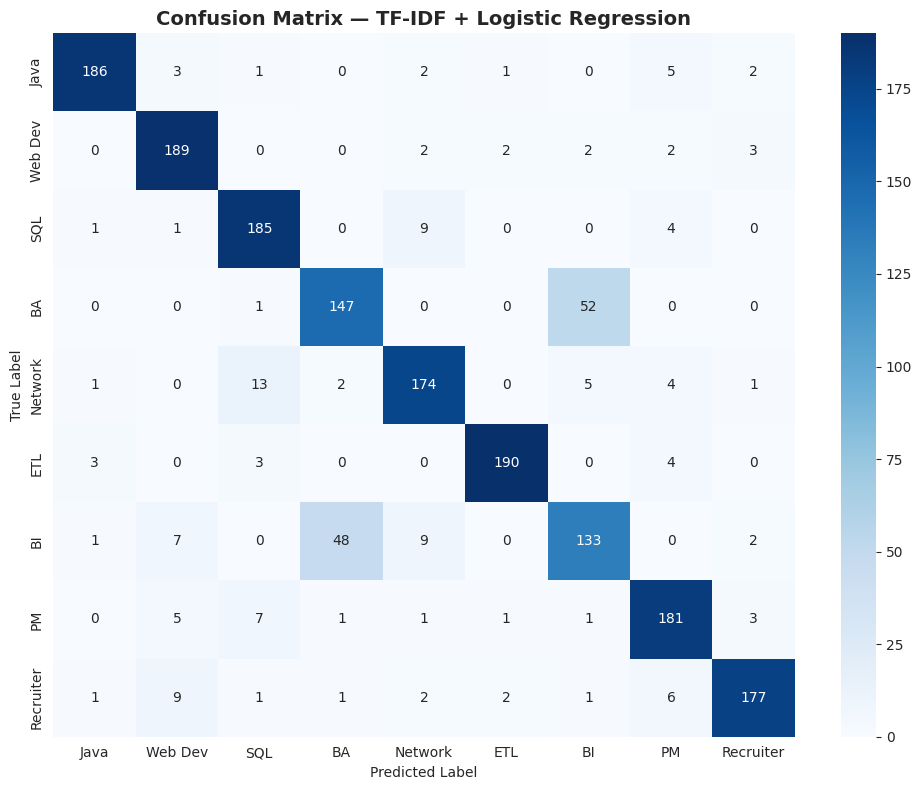

In [28]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
short_labels = [
    'Java', 'Web Dev', 'SQL', 'BA', 'Network',
    'ETL', 'BI', 'PM', 'Recruiter'
]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_labels, yticklabels=short_labels)
plt.title('Confusion Matrix — TF-IDF + Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. SBERT Classification Baseline

In [29]:
X_sbert = sbert_embeddings

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sbert, y, test_size=0.2, random_state=42, stratify=y
)

clf_sbert = LogisticRegression(max_iter=500, C=1.0)
clf_sbert.fit(X_train_s, y_train_s)

y_pred_s = clf_sbert.predict(X_test_s)
acc_s = accuracy_score(y_test_s, y_pred_s)
print(f'✅ SBERT + Logistic Regression Accuracy: {acc_s:.2%}\n')
print(classification_report(y_test_s, y_pred_s, target_names=le.classes_))

✅ SBERT + Logistic Regression Accuracy: 84.83%

                                                precision    recall  f1-score   support

                 Business Analyst (BA) Resumes       0.93      0.94      0.93       200
Business Intelligence, Business Object Resumes       0.91      0.91      0.91       200
     Datawarehousing, ETL, Informatica Resumes       0.86      0.86      0.86       200
            Java Developers/Architects Resumes       0.75      0.76      0.75       200
    Network and Systems Administrators Resumes       0.82      0.81      0.82       200
                       Project Manager Resumes       0.95      0.94      0.94       200
                             Recruiter Resumes       0.69      0.65      0.67       200
                        SQL Developers Resumes       0.82      0.90      0.86       200
                         Web Developer Resumes       0.91      0.86      0.88       200

                                      accuracy                        

## 10. Interactive Resume Screener

In [30]:
def screen_and_compare(job_description, top_n=5):
    """
    Screen resumes using both TF-IDF and SBERT, display side-by-side.
    """
    print(f'\n📋 JOB DESCRIPTION (excerpt):')
    print(job_description.strip()[:200])
    print('\n' + '='*70)

    r_tfidf = screen_resumes_tfidf(job_description, top_n)
    r_sbert  = screen_resumes_sbert(job_description, top_n)

    print(f'\n🔵 TF-IDF Top {top_n}:')
    print(r_tfidf[['rank','job_title','category','tfidf_score']].to_string(index=False))

    print(f'\n🟠 SBERT Top {top_n}:')
    print(r_sbert[['rank','job_title','category','sbert_score']].to_string(index=False))


# ── Try with a custom job description ──
custom_jd = """
    We need a Data Warehouse Engineer with 4+ years of experience.
    Proficiency in Informatica PowerCenter, SQL Server Integration Services (SSIS),
    dimensional modeling, and ETL pipeline design is required.
    Experience with AWS Redshift or Snowflake is a strong advantage.
"""

screen_and_compare(custom_jd, top_n=5)


📋 JOB DESCRIPTION (excerpt):
We need a Data Warehouse Engineer with 4+ years of experience.
    Proficiency in Informatica PowerCenter, SQL Server Integration Services (SSIS),
    dimensional modeling, and ETL pipeline design is 


🔵 TF-IDF Top 5:
 rank                                                   job_title                                   category  tfidf_score
    1                                   ETL/Informatica Developer                      Web Developer Resumes       0.1853
    2                                   ETL/Informatica Developer                      Web Developer Resumes       0.1853
    3                                             System Engineer Network and Systems Administrators Resumes       0.1810
    4                                        Sr. Talend Developer                      Web Developer Resumes       0.1750
    5 Senior Solution & Data Architect/Data Modeler/ETL Developer                      Web Developer Resumes       0.1675

🟠 SBERT Top 5:
 ra

## 11. Summary & Conclusions

In [31]:
print('=' * 70)
print('                   📊 PROJECT SUMMARY')
print('=' * 70)
print(f'  Dataset:          9,000 resumes | 9 IT categories')
print(f'  Task:             Resume screening & ranking vs job descriptions')
print()
print('  ── Screening (Ranking) ──────────────────────────────────────────')
print(f'  TF-IDF Avg Precision@10:  {np.mean(list(tfidf_precision.values())):.1%}')
print(f'  SBERT  Avg Precision@10:  {np.mean(list(sbert_precision.values())):.1%}')
print()
print('  ── Classification (Category Prediction) ──────────────────────')
print(f'  TF-IDF + LogReg Accuracy: {acc:.2%}')
print(f'  SBERT  + LogReg Accuracy: {acc_s:.2%}')
print()
print('  ── Key Insights ──────────────────────────────────────────────')
print('  • TF-IDF is fast and great for keyword-heavy technical roles')
print('  • SBERT captures semantic meaning — better for hybrid/general JDs')
print('  • Combining both (ensemble) often yields best results in production')
print('=' * 70)

                   📊 PROJECT SUMMARY
  Dataset:          9,000 resumes | 9 IT categories
  Task:             Resume screening & ranking vs job descriptions

  ── Screening (Ranking) ──────────────────────────────────────────
  TF-IDF Avg Precision@10:  15.6%
  SBERT  Avg Precision@10:  20.0%

  ── Classification (Category Prediction) ──────────────────────
  TF-IDF + LogReg Accuracy: 86.78%
  SBERT  + LogReg Accuracy: 84.83%

  ── Key Insights ──────────────────────────────────────────────
  • TF-IDF is fast and great for keyword-heavy technical roles
  • SBERT captures semantic meaning — better for hybrid/general JDs
  • Combining both (ensemble) often yields best results in production
